In [1]:
import dataclasses
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats

from lib.plots import set_axis, faint_color
from lib.stats import fit_power_law

In [2]:
task_ids = {
    "1a":        "task-1a-control",
    "1b":        "task-1b-control",
    "2-noc":     "task-2-delcohesin",
    "3a-ac":     "task-3a-ac",
    "3b-ac":     "task-3b-ac",
    "4-ac-noc":  "task-4-ac_delcohesin",

    "5":         "task-5-control",
    "6-noc":     "task-6-nocohesin",
    "7":         "task-7-control",
    "8-noc":     "task-8-nocohesin",

    "9":         "task-9-control",
    "10-noc":    "task-10-nocohesin",
    "11-ac":     "task-11-ac",
    "12-ac-noc": "task-12-ac_nocohesin",

    "13":        "task-13-control",
    "14-noc":    "task-14-nocohesin",
    "15-ac":     "task-15-ac",
    "16-ac-noc": "task-16-ac_nocohesin",

    "17":        "task-17-control",
    "18-noc":    "task-18-nocohesin",
    "19-ac":     "task-19-ac",
    "20-ac-noc": "task-20-ac_nocohesin",

    "21":        "task-21-control",
    "22-noc":    "task-22-nocohesin",
    "23":        "task-23-control",
    "24-noc":    "task-24-nocohesin",
    "25":        "task-25-control",
    "26-noc":    "task-26-nocohesin",
    "28-noc":    "task-28-nocohesin",
    "29":        "task-29-control",
    "30-noc":    "task-30-nocohesin",
    "31":        "task-31-control",
    "32-noc":    "task-32-nocohesin",
    "33":        "task-33-control",
    "34-noc":    "task-34-nocohesin",
    "35":        "task-35-control",
    "36-noc":    "task-36-nocohesin",
    "37":        "task-37-control",
    "38-noc":    "task-38-nocohesin",
    "39":        "task-39-control",
    "40-noc":    "task-40-nocohesin",
    "41":        "task-41-control",
    "42":        "task-42-control",
    "43":        "task-43-control",
    "44-noc":    "task-44-nocohesin",
    "47":        "task-47-control",

    "48":        "48-control",
    "49":        "49-control",
    "50-noc":    "50-nocohesin",
    "51-ac":     "51-ac",
    "52-ac":     "52-ac",
    "53-ac_noc": "53-ac_nocohesin",
}

@dataclasses.dataclass
class Metrics:
    files: list[str]
    config: dict
    site_msds: np.ndarray
    domain_rgs: np.ndarray
    domain_distances: np.ndarray
    separation_scores: np.ndarray
    mixing_scores: np.ndarray

conds_metrics = {}

for key, task_id in task_ids.items():
    with h5py.File(f"{task_id}/_outputs/metrics-nocen.h5", "r") as store:
        conds_metrics[key] = Metrics(
            files=[s.decode() for s in store["files"][()]],
            config=json.loads(store["config"][()]),
            site_msds=store["site_msds"][:, :, :],
            domain_rgs=store["domain_rgs"][:],
            domain_distances=store["domain_distances"][:],
            separation_scores=store["separation_scores"][:],
            mixing_scores=(1 / store["separation_scores"][:]),
        )

In [3]:
@dataclasses.dataclass
class MSDAnalysis:
    lags: np.ndarray
    means: np.ndarray
    stds: np.ndarray
    alpha: float
    beta: float
    whole_sample: np.ndarray            # (traj * site, time)
    replicate_wise_sample: np.ndarray   # (traj, time) site-averaged

In [4]:
reference_lag = 10
average_across_sites = False

conds_msds = {}

for key, metrics in conds_metrics.items():
    config = metrics.config
    sampling_config = config["sampling"]
    phase_overrides = sampling_config["phases"][-1]
    phase_config = {**sampling_config, **phase_overrides}
    frame_interval = phase_config["timestep"] * phase_config["sampling_interval"]

    site_msds = metrics.site_msds[:, :reference_lag + 1, :]
    lags = np.arange(site_msds.shape[1]) * frame_interval

    if average_across_sites:
        msd_samples = site_msds.mean(axis=2)
    else:
        msd_samples = einops.rearrange(site_msds, "r t s -> (r s) t")

    msd_mean = msd_samples.mean(axis=0)
    msd_std = msd_samples.std(axis=0)

    x = lags
    y = msd_mean
    alpha, beta = fit_power_law(x, y)

    conds_msds[key] = MSDAnalysis(
        lags=lags,
        means=msd_mean,
        stds=msd_std,
        alpha=alpha,
        beta=beta,
    )

In [5]:
for key, msd in conds_msds.items():
    print("{:10s} α={:.3f} Deff={:.3g}".format(key, msd.alpha, msd.beta))

1a         α=0.520 Deff=12
1b         α=0.527 Deff=12.5
2-noc      α=0.535 Deff=14
3a-ac      α=0.519 Deff=24.4
3b-ac      α=0.541 Deff=26.6
4-ac-noc   α=0.570 Deff=32.9
5          α=0.532 Deff=13.6
6-noc      α=0.541 Deff=15.5
7          α=0.484 Deff=8.97
8-noc      α=0.535 Deff=14.7
9          α=0.486 Deff=8.65
10-noc     α=0.497 Deff=9.58
11-ac      α=0.439 Deff=12.8
12-ac-noc  α=0.464 Deff=14.7
13         α=0.520 Deff=11.9
14-noc     α=0.529 Deff=13.2
15-ac      α=0.505 Deff=22.5
16-ac-noc  α=0.523 Deff=26.4
17         α=0.512 Deff=11.2
18-noc     α=0.514 Deff=12.1
19-ac      α=0.475 Deff=19
20-ac-noc  α=0.495 Deff=21.8
21         α=0.548 Deff=19.9
22-noc     α=0.566 Deff=24.6
23         α=0.541 Deff=24.1
24-noc     α=0.565 Deff=29.6
25         α=0.522 Deff=12.6
26-noc     α=0.542 Deff=14.7
28-noc     α=0.577 Deff=26.6
29         α=0.533 Deff=15.1
30-noc     α=0.547 Deff=17.1
31         α=0.520 Deff=14.4
32-noc     α=0.533 Deff=16.1
33         α=0.535 Deff=15.4
34-noc     α=0.549 D

In [6]:
@dataclasses.dataclass
class ConditionSpec:
    key:    str
    color:  any
    offset: float
    label:  str


conditions = [
    #ConditionSpec(key="7",     color="k", offset=1, label="control"),
    #ConditionSpec(key="8-noc", color="r", offset=2, label="Δcohesin"),

    #ConditionSpec(key="1b",    color="k", offset=1, label="control"),
    #ConditionSpec(key="2-noc", color="r", offset=2, label="Δcohesin"),

    #ConditionSpec(key="9",         color="k", offset=1, label="control"),
    #ConditionSpec(key="10-noc",    color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="11-ac",     color="C:y", offset=3, label="ac++"),
    #ConditionSpec(key="12-ac-noc", color="m", offset=4, label="ac++ Δcohesin"),

    #ConditionSpec(key="13",         color="k", offset=1, label="control"),
    #ConditionSpec(key="14-noc",    color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="15-ac",     color="C:y", offset=3, label="ac++"),
    #ConditionSpec(key="16-ac-noc", color="m", offset=4, label="ac++ Δcohesin"),

    #ConditionSpec(key="17",         color="k", offset=1, label="control"),
    #ConditionSpec(key="18-noc",    color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="19-ac",     color="C:y", offset=3, label="ac++"),
    #ConditionSpec(key="20-ac-noc", color="m", offset=4, label="ac++ Δcohesin"),

    #ConditionSpec(key="21",     color="k", offset=1, label="control"),
    #ConditionSpec(key="22-noc", color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="23",     color="k", offset=3, label="control"),
    #ConditionSpec(key="24-noc", color="r", offset=4, label="Δcohesin"),
    #ConditionSpec(key="25",     color="k", offset=1, label="control"),
    #ConditionSpec(key="26-noc", color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="27",     color="k", offset=1, label="control"),
    #ConditionSpec(key="28-noc", color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="29",     color="k", offset=1, label="control"),
    #ConditionSpec(key="30-noc", color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="31",     color="k", offset=1, label="control"),
    #ConditionSpec(key="32-noc", color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="33",     color="k", offset=1, label="control"),
    #ConditionSpec(key="34-noc", color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="35",     color="k", offset=1, label="control"),
    #ConditionSpec(key="36-noc", color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="37",     color="k", offset=1, label="control"),
    #ConditionSpec(key="38-noc", color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="39",     color="k", offset=1, label="control"),
    #ConditionSpec(key="40-noc", color="r", offset=2, label="Δcohesin"),

    #ConditionSpec(key="41",     color="k", offset=1, label="control"),
    #ConditionSpec(key="42",     color="k", offset=1, label="control"),
    #ConditionSpec(key="43",     color="k", offset=1, label="control"),
    #ConditionSpec(key="44-noc", color="r", offset=2, label="Δcohesin"),

    #ConditionSpec(key="47",     color="k", offset=1, label="control"),
    #ConditionSpec(key="48",     color="k", offset=1, label="control"),
    #ConditionSpec(key="49",     color="k", offset=1, label="control"),
    #ConditionSpec(key="50-noc", color="r", offset=2, label="Δcohesin"),

    #ConditionSpec(key="48",        color="k", offset=1, label="control"),
    #ConditionSpec(key="49",        color="k", offset=1, label="control"),
    #ConditionSpec(key="50-noc",    color="r", offset=2, label="Δcohesin"),
    #ConditionSpec(key="51-ac",     color="C:y", offset=3, label="ac++"),
    #ConditionSpec(key="52-ac",     color="C:y", offset=3, label="ac++"),
    #ConditionSpec(key="53-ac_noc", color="C:m", offset=4, label="ac++ Δcohesin"),

    # ConditionSpec(key="49",        color="#000", offset=1, label="control"),
    # ConditionSpec(key="50-noc",    color="red",  offset=2, label="Δcohesin"),

    #ConditionSpec(key="49",        color="#666", offset=2, label="loops (no crossing)"),
    #ConditionSpec(key="48",        color="#000", offset=1, label="loops"),
    #ConditionSpec(key="50-noc",    color="red",  offset=3, label="Δcohesin"),
    #ConditionSpec(key="52-ac",     color="#a9e",  offset=5, label="ac++ loops (no crossing)"),
    #ConditionSpec(key="51-ac",     color="#66c",  offset=4, label="ac++ loops"),
    #ConditionSpec(key="53-ac_noc", color="C:y",  offset=6, label="ac++ Δcohesin"),

    ConditionSpec(key="49",        color="C:m", offset=1, label="random"),
    ConditionSpec(key="48",        color="k",   offset=2, label="no crossing"),
    ConditionSpec(key="50-noc",    color="red", offset=3, label="Δcohesin"),
]

In [7]:
msd_means = np.array([
    conds_metrics[cond.key].site_msds[:, reference_lag, :].mean()
    for cond in conditions
])
msd_fcs = msd_means[1:] / msd_means[0]

print("MSD:")
for cond, fc in zip(conditions[1:], msd_fcs):
    print("  {:10s} {:.2f}x".format(cond.label, fc))

mix_means = np.array([
    conds_metrics[cond.key].mixing_scores.mean()
    for cond in conditions
])
mix_fcs = mix_means[1:] / mix_means[0]

print("Mixing:")
for cond, fc in zip(conditions[1:], mix_fcs):
    print("  {:10s} {:.2f}x".format(cond.label, fc))

MSD:
  no crossing 1.04x
  Δcohesin   1.19x
Mixing:
  no crossing 1.02x
  Δcohesin   1.22x


In [8]:
msd_values = np.array([
    conds_metrics[cond.key].site_msds[:, reference_lag, :]
    for cond in conditions
])

for i, cond_i in enumerate(conditions):
    for j, cond_j in enumerate(conditions):
        if i >= j:
            continue
        whole_test = scipy.stats.ttest_rel(
            msd_values[i].ravel(),
            msd_values[j].ravel(),
        )
        site_avg_test = scipy.stats.ttest_rel(
            msd_values[i].mean(axis=-1),
            msd_values[j].mean(axis=-1),
        )
        print(cond_i.label, "vs", cond_j.label)
        print("  ", whole_test)
        print("  ", site_avg_test)

random vs no crossing
   TtestResult(statistic=-7.738397732920745, pvalue=1.2627458886109242e-14, df=4049)
   TtestResult(statistic=-2.273439123982637, pvalue=0.04908628706289671, df=9)
random vs Δcohesin
   TtestResult(statistic=-44.67354637044995, pvalue=0.0, df=4049)
   TtestResult(statistic=-20.297029324844058, pvalue=7.972181707456039e-09, df=9)
no crossing vs Δcohesin
   TtestResult(statistic=-30.923326046622833, pvalue=1.1090204839452209e-188, df=4049)
   TtestResult(statistic=-9.083771452845284, pvalue=7.914349196784712e-06, df=9)


In [84]:
mixing_scores = np.array([
    conds_metrics[cond.key].mixing_scores
    for cond in conditions
])

for i, cond_i in enumerate(conditions):
    for j, cond_j in enumerate(conditions):
        if i >= j:
            continue
        whole_test = scipy.stats.ttest_ind(
            mixing_scores[i].ravel(),
            mixing_scores[j].ravel(),
        )
        time_avg_test = scipy.stats.ttest_ind(
            mixing_scores[i].mean(axis=-1),
            mixing_scores[j].mean(axis=-1),
        )
        print(cond_i.label, "vs", cond_j.label)
        print("  ", whole_test)
        print("  ", time_avg_test)

random vs no crossing
   TtestResult(statistic=-10.298838890188227, pvalue=8.225039272534265e-25, df=20018.0)
   TtestResult(statistic=-0.8330258449556068, pvalue=0.4157471376705235, df=18.0)
random vs Δcohesin
   TtestResult(statistic=-125.34111782424948, pvalue=0.0, df=20018.0)
   TtestResult(statistic=-10.582538755785391, pvalue=3.710820571171892e-09, df=18.0)
no crossing vs Δcohesin
   TtestResult(statistic=-108.77064861441377, pvalue=0.0, df=20018.0)
   TtestResult(statistic=-9.610531913381008, pvalue=1.640059487323994e-08, df=18.0)


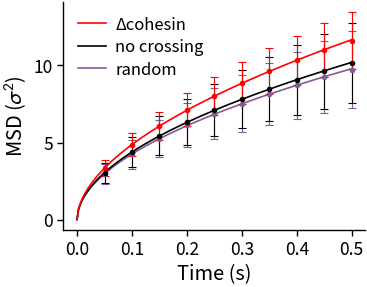

In [94]:
fig, ax = plt.subplots(figsize=(1.9, 1.5))
# fig, ax = plt.subplots(figsize=(2.2, 2.0))

for cond in conditions:
    msd = conds_msds[cond.key]

    x = msd.lags[1:]
    y = msd.means[1:]
    y_err = msd.stds[1:]
    ax.errorbar(
        x, y, y_err,
        color=cond.color,
        marker="o",
        markersize=1,
        linewidth=0,
        elinewidth=0.4,
        capsize=1.3,
        capthick=0.4,
        zorder=2,
    )

    x = np.linspace(msd.lags[0], msd.lags[-1], num=200)
    y = x**msd.alpha * msd.beta
    ax.plot(x, y, lw=0.6, color=cond.color, label=cond.label)

ax.legend(frameon=True)
ax.set_xticks(np.arange(0, 0.51, 0.1))
ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])

set_axis(ax, "left bottom")

fig.savefig("_figs/MSD_curve.svg")

pass

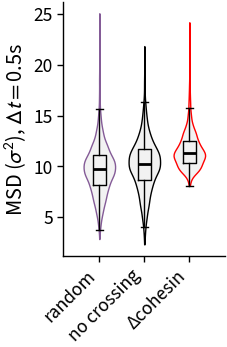

In [93]:
fig, ax = plt.subplots(figsize=(1.2, 1.8))

data = [
    conds_metrics[cond.key].site_msds[:, reference_lag, :].ravel()
    for cond in conditions
]
xs = [cond.offset for cond in conditions]

violins = ax.violinplot(
    data,
    xs,
    widths=0.7,
    showextrema=False,
    showmedians=False,
)

for cond, body in zip(conditions, violins["bodies"]):
    body.set_facecolor("0.95")
    body.set_edgecolor(cond.color)
    body.set_alpha(1)

ax.boxplot(
    data,
    positions=xs,
    showbox=True,
    showcaps=True,
    showfliers=False,
    capprops=dict(linewidth=0.5, color="k"),
    whiskerprops=dict(linewidth=0.5, color="k"),
    boxprops=dict(linewidth=0.5, color="k"),
    medianprops=dict(linewidth=1, color="k"),
)

ax.set_xticks(xs)
ax.set_xticklabels([cond.label for cond in conditions], ha="right", rotation=45)
ax.set_ylabel(r"MSD ($ \sigma^2 $), $ \Delta t = $0.5s")

ax.set_xlim(0.2, len(conditions) + 0.8)

set_axis(ax, "left bottom")

fig.savefig("_figs/MSD_violin.svg")

pass

In [108]:
mean_msds = [
    conds_metrics[cond.key].site_msds[:, reference_lag, :].mean(axis=-1)
    for cond in conditions
]

mmsd_means = [msds.mean() for msds in mean_msds]
mmsd_fcs = [mmsd / mmsd_means[0] for mmsd in mmsd_means[1:]]

print("M-MSD:")
for cond, fc in zip(conditions[1:], mmsd_fcs):
    print("  {:10s} {:.2f}x".format(cond.label, fc))

M-MSD:
  no crossing 1.04x
  Δcohesin   1.19x


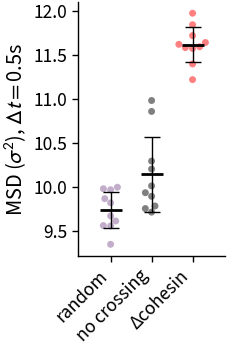

In [114]:
fig, ax = plt.subplots(figsize=(1.2, 1.8))

sns.swarmplot(
    {cond.label: msds for cond, msds in zip(conditions, mean_msds)},
    palette=[faint_color(cond.color) for cond in conditions],
    size=2.5,
    zorder=1,
    ax=ax,
)

ax.errorbar(
    np.arange(len(conditions)),
    [msds.mean() for msds in mean_msds],
    [msds.std() for msds in mean_msds],
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color=c,
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.set_ylabel(r"MSD ($ \sigma^2 $), $ \Delta t = $0.5s")

ax.set_xlim(-0.8, len(conditions) - 0.2)
 
set_axis(ax, "left bottom")

fig.savefig("_figs/MSD_swarm.svg")

pass

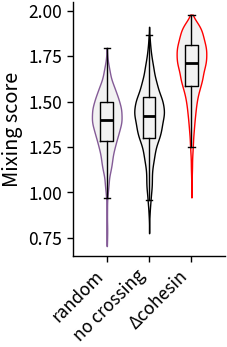

In [92]:
fig, ax = plt.subplots(figsize=(1.2, 1.8))

data = [
    conds_metrics[cond.key].mixing_scores.ravel()
    for cond in conditions
]
xs = [cond.offset for cond in conditions]

violins = ax.violinplot(
    data,
    positions=xs,
    widths=0.7,
    showextrema=False,
)

for cond, body in zip(conditions, violins["bodies"]):
    body.set_facecolor("0.95")
    body.set_edgecolor(cond.color)
    body.set_alpha(1)

ax.boxplot(
    data,
    positions=xs,
    showbox=True,
    showcaps=True,
    showfliers=False,
    capprops=dict(linewidth=0.5, color="k"),
    whiskerprops=dict(linewidth=0.5, color="k"),
    boxprops=dict(linewidth=0.5, color="k"),
    medianprops=dict(linewidth=1, color="k"),
)

ax.set_xticks(xs)
ax.set_xticklabels([cond.label for cond in conditions], ha="right", rotation=45)
ax.set_ylabel("Mixing score")
ax.set_xlim(0.2, len(conditions) + 0.8)
ax.set_ylim(0.65, 2.05)

set_axis(ax, "left bottom")

fig.savefig("_figs/Mixing_violin.svg")

pass